# Running 21-cm simulations with primordial non-Gaussianity

This notebook walks through running `21cmFirstCLASS_NG` with a local primordial
non-Gaussianity of amplitude $f_{\rm NL}$, and comparing the result against the
Gaussian baseline.

It uses `runsims_FNL.py`, which sits alongside this notebook and wraps the
lightcone call, the caching, and the plotting.

**Before you start.** A single lightcone at the settings used here takes of
order an hour on a few cores, and the parameter grid in section 5 multiplies
that. Start with the smallest box, confirm the pipeline works end to end, and
only then scale up.

**Prerequisites**

* `21cmFirstCLASS_NG` installed (see the README)
* `classy`, the CLASS Python wrapper
* enough memory: with `NON_GAUSS_IC = True` the de-aliasing grid is
  `EXTRA_DIM_FNL` times `DIM` on a side, and memory scales as its cube

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import runsims_FNL as rs

# Where runs and figures are written. Nothing is created until you call this.
rs.set_output_folder('./fnl_runs/')

# Optional: LaTeX text rendering in the figures. Needs a LaTeX installation,
# and fails at draw time rather than here, so it is off by default.
# rs.use_latex_fonts()

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

## 1. What the flags mean

Non-Gaussianity enters `21cmFirstCLASS_NG` in three independent places, and
each can be switched on separately. Running them one at a time is the only way
to see which one is responsible for a change in the signal.

| Flag | Where it acts | What it changes |
|---|---|---|
| `NON_GAUSS_IC` | initial conditions | the density field is built from a non-Gaussian potential, $\Phi = \Phi_G + f_{\rm NL}(\Phi_G^2 - \langle\Phi_G^2\rangle)$ |
| `NON_GAUSS_FCOLL_COND` | conditional halo mass function | the collapsed fraction in each cell |
| `NON_GAUSS_FCOLL_UNCOND` | unconditional halo mass function | the global ionizing emissivity |

Each correction also has a choice of approximation:

| Flag | Default | Alternative |
|---|---|---|
| `USE_EDG_uncond_hmf` | Edgeworth expansion ([arXiv:2009.01245](https://arxiv.org/abs/2009.01245)) | saddlepoint |
| `USE_LD_cond_hmf` | Lidz / D'Aloisio closed form | two-scale saddlepoint |
| `NG_MODEL_APPROX` | high-barrier limit ([arXiv:1304.8049](https://arxiv.org/abs/1304.8049)) | full expression ([arXiv:1206.3305](https://arxiv.org/abs/1206.3305)) |

The two approximations in each row agree at small $|f_{\rm NL}|$ and separate
where the expansion breaks down. 


In [1]:
Lbox = 300.     # comoving Mpc
Nbox = 150      # cells per side

## 2. A first pair of runs

We start with the Gaussian baseline and one non-Gaussian run. `import_stuff`
loads a cached result if it exists and runs the simulation otherwise, so
re-executing this cell is cheap once the runs are done.

The code currently sets `USE_MINI_HALOS = False` by default, keeping Population III stars out.
Note that non-Gaussianity is *not* implemented in the mini-halo collapse fraction, so if you turn this flag to `True` you will obtain an inconsistent result. 

In [3]:
fnl_test = 100.

common = dict(force_mmax=0.,          # no upper mass cut on the integrals
              kcut_fnl=1e-3,          # scale-independent for this box
              USE_MINI_HALOS=False,
              nongauss_IC=True,
              nongauss_fcollcond=True,
              nongauss_fcolluncond=True,
              use_lidz_approx=False,
              use_ld_cond=True,
              use_edg_uncond=True,
              max_epsilon=0.,
              extra_dim_fnl=1.)      # Orszag 3/2 de-aliasing

Gauss = rs.import_stuff(Lbox, Nbox, fnl=0.,        **common)
NG    = rs.import_stuff(Lbox, Nbox, fnl=fnl_test,  **common)
NGm   = rs.import_stuff(Lbox, Nbox, fnl=-fnl_test, **common)

print("loaded three runs")

Could not read ./fnl_runs/300.0,150,Gaus.pkl (FileNotFoundError): running the simulation.
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [36:26<00:00, 26.03s/redshift]


Could not read ./fnl_runs/300.0,150,100.0.pkl (FileNotFoundError): running the simulation.
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [41:42<00:00, 29.79s/redshift]


Could not read ./fnl_runs/300.0,150,-100.0.pkl (FileNotFoundError): running the simulation.
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [37:07<00:00, 26.52s/redshift]


loaded three runs


## 3. The global signal

The first thing to look at is the sky-averaged brightness temperature and the
neutral fraction. Positive $f_{\rm NL}$ raises the abundance of rare haloes,
which brings X-ray heating and reionization forward; negative $f_{\rm NL}$ delays it.

In [5]:
print(rs.run_filename(Lbox, Nbox, 0.,        **common))
print(rs.run_filename(Lbox, Nbox, fnl_test,  **common))
print(rs.run_filename(Lbox, Nbox, -fnl_test, **common))

./fnl_runs/300.0,150,Gaus.pkl
./fnl_runs/300.0,150,100.0.pkl
./fnl_runs/300.0,150,-100.0.pkl


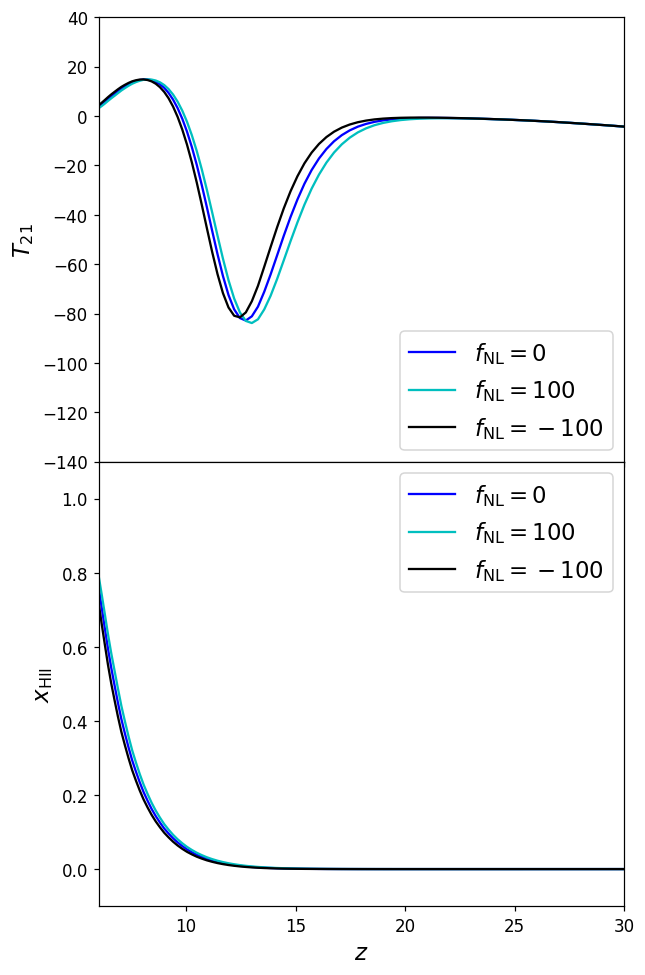

In [6]:
rs.plot_globals(Lbox, Nbox, [0., fnl_test, -fnl_test],
                force_mmax=common['force_mmax'],
                kcut_fnl=common['kcut_fnl'],
                USE_MINI_HALOS=common['USE_MINI_HALOS'])

## 4. The power spectrum

The 21-cm power spectrum is where a survey would actually look. Plotting the
ratio to the Gaussian run rather than the spectra themselves removes most of the
shape and leaves the non-Gaussian signal.

Because both runs share a random seed, the ratio is not dominated by cosmic
variance on large scales — but it is still a single realisation, so do not read
too much into a feature seen in one box.

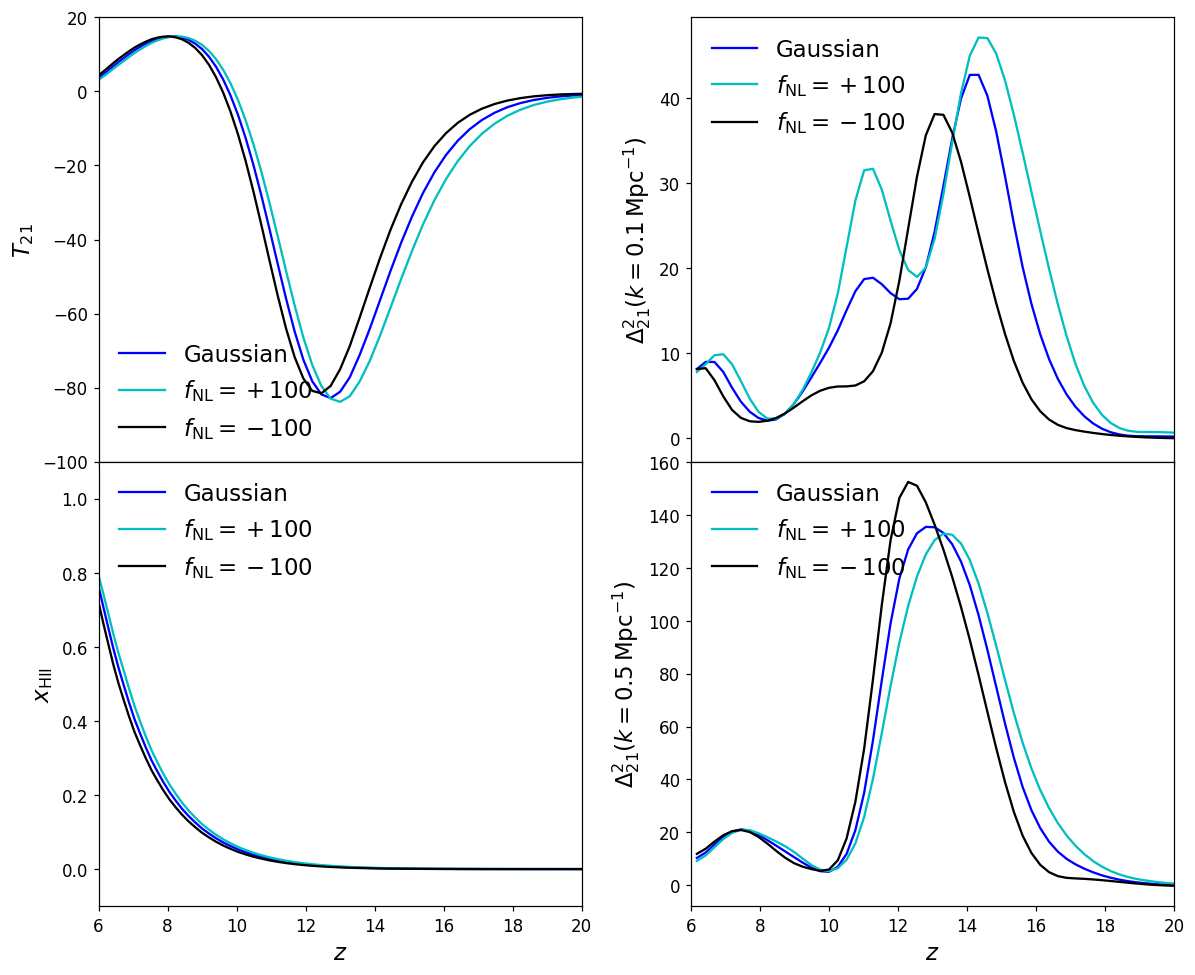

In [7]:
compare = [Gauss, NG, NGm]
labels = ['Gaussian',
          rf'$f_{{\rm NL}} = +{fnl_test:.0f}$',
          rf'$f_{{\rm NL}} = -{fnl_test:.0f}$']

rs.plot_compare_multi(k_vals=[0.1, 0.5],
                      list_to_compare=compare,
                      list_labels=labels,
                      list_colors=rs.use_colors,
                      list_ls=['-', '-', '-'],
                      filename= 'compare_pk.png',)

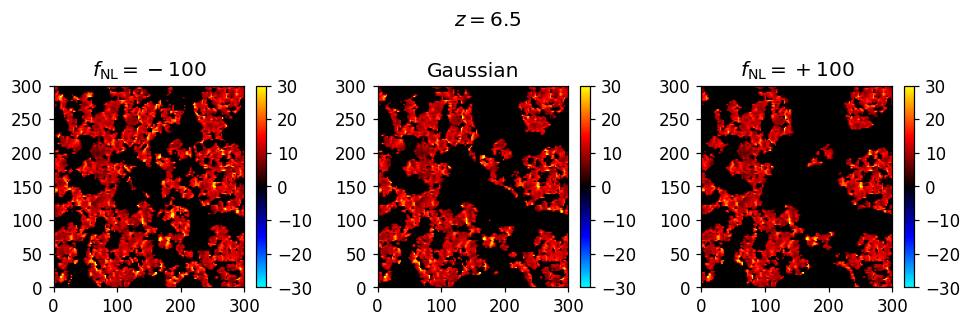

In [8]:
# Coeval slices: the Gaussian box and the difference from it
rs.plot_compare_boxes(0, Lbox, compare, list_labels=labels,                       
                      filename= 'compare_boxes.png',)

## 5. Isolating where the effect comes from

With all three flags on, a change in the signal could come from the initial
conditions, the conditional mass function, the unconditional one, or any
combination. Switching them on one at a time separates the contributions.


In [9]:
variants = {
    'IC only':          dict(nongauss_IC=True,  nongauss_fcollcond=False, nongauss_fcolluncond=False),
    'conditional only': dict(nongauss_IC=False, nongauss_fcollcond=True,  nongauss_fcolluncond=False),
    'unconditional only': dict(nongauss_IC=False, nongauss_fcollcond=False, nongauss_fcolluncond=True),
    'all three':        dict(nongauss_IC=True,  nongauss_fcollcond=True,  nongauss_fcolluncond=True),
}

runs = {}
for name, flags in variants.items():
    kw = dict(common); kw.update(flags)
    runs[name] = rs.import_stuff(Lbox, Nbox, fnl=fnl_test, **kw)
    print(f"  {name:20s} -> {rs.run_filename(Lbox, Nbox, fnl_test, **kw)}")

Could not read ./fnl_runs/300.0,150,100.0_noNGfcolCOND_noNGfcolUNCOND.pkl (FileNotFoundError): running the simulation.
Now running CLASS...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [35:36<00:00, 25.44s/redshift]


  IC only              -> ./fnl_runs/300.0,150,100.0_noNGfcolCOND_noNGfcolUNCOND.pkl
Could not read ./fnl_runs/300.0,150,100.0_noNGIC_noNGfcolUNCOND.pkl (FileNotFoundError): running the simulation.
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [39:34<00:00, 28.27s/redshift]


  conditional only     -> ./fnl_runs/300.0,150,100.0_noNGIC_noNGfcolUNCOND.pkl
Could not read ./fnl_runs/300.0,150,100.0_noNGIC_noNGfcolCOND.pkl (FileNotFoundError): running the simulation.
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [39:00<00:00, 27.87s/redshift]


  unconditional only   -> ./fnl_runs/300.0,150,100.0_noNGIC_noNGfcolCOND.pkl
  all three            -> ./fnl_runs/300.0,150,100.0.pkl


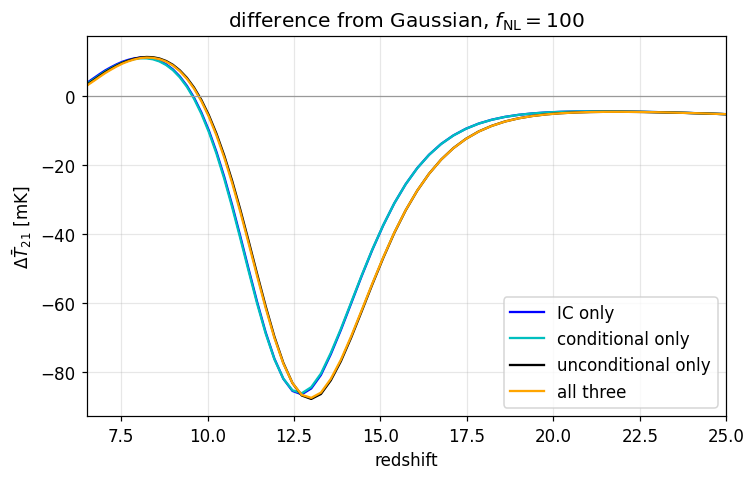

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))

z_g, T_g = Gauss[0], Gauss[1]
for name, r in runs.items():
    ax.plot(r[0], np.array(r[1]) - np.interp(r[0], z_g, T_g), label=name)

ax.axhline(0., color='0.6', lw=.8)
ax.set(xlabel='redshift', ylabel=r'$\Delta \bar{T}_{21}$ [mK]',
       title=rf'difference from Gaussian, $f_{{\rm NL}} = {fnl_test:.0f}$',
       xlim=(6.5, 25), )
ax.legend(); ax.grid(alpha=.3)
fig.tight_layout()

## 6. Choice of approximation as a systematic

The Edgeworth and saddlepoint schemes are two truncations of the same
expansion. Where both are valid they agree; where they separate, at least one
has broken down. 

The same applies to `USE_LD_cond_hmf` on the conditional side.

Could not read ./fnl_runs/300.0,150,100.0_UNCONDsaddle.pkl (FileNotFoundError): running the simulation.
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [36:29<00:00, 26.06s/redshift]


largest difference between the two schemes: 0.171 mK


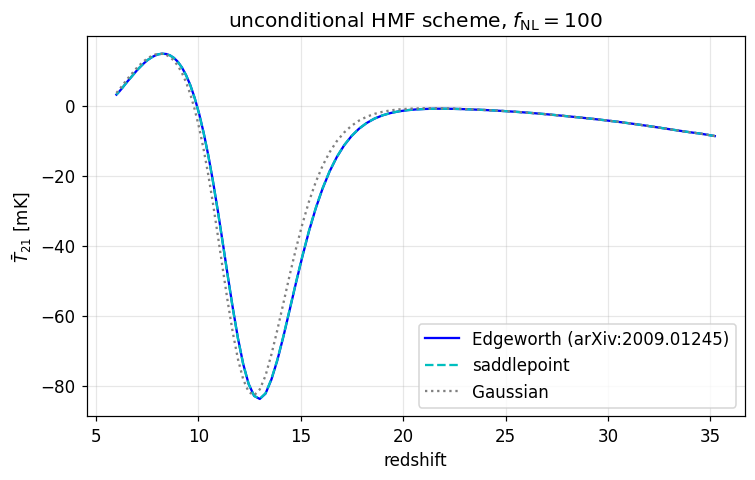

In [14]:
kw_edg = dict(common); kw_edg['use_edg_uncond'] = True
kw_sad = dict(common); kw_sad['use_edg_uncond'] = False

edg = rs.import_stuff(Lbox, Nbox, fnl=fnl_test, **kw_edg)
sad = rs.import_stuff(Lbox, Nbox, fnl=fnl_test, **kw_sad)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(edg[0], edg[1], label='Edgeworth (arXiv:2009.01245)')
ax.plot(sad[0], sad[1], '--', label='saddlepoint')
ax.plot(z_g, T_g, ':', color='0.5', label='Gaussian')
ax.set(xlabel='redshift', ylabel=r'$\bar{T}_{21}$ [mK]',
       title=rf'unconditional HMF scheme, $f_{{\rm NL}} = {fnl_test:.0f}$')
ax.legend(); ax.grid(alpha=.3)
fig.tight_layout()

spread = np.max(np.abs(np.array(edg[1]) - np.array(sad[1])))
print(f"largest difference between the two schemes: {spread:.3f} mK")